In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv("data/raw/US_Accidents_March23_sampled_500k.csv")
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,...,False,False,False,False,True,False,Day,Day,Day,Day
3,A-4237356,Source1,2,2022-02-21 17:43:04,2022-02-21 19:43:23,43.680592,-92.993317,43.680574,-92.972223,1.054,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-6690583,Source1,2,2020-12-04 01:46:00,2020-12-04 04:13:09,35.395484,-118.985176,35.395476,-118.985995,0.046,...,False,False,False,False,False,False,Night,Night,Night,Night


In [3]:
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

Rows: 500,000
Columns: 46


In [4]:
# Missing data analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Missing_Percentage': missing_pct.values,
    'Data Type': missing.index.map(df.dtypes),
}).sort_values('Missing_Percentage', ascending=False)

# Show only columns with missing data
print("MISSING DATA SUMMARY")
print(missing_df[missing_df['Missing_Count'] > 0])

MISSING DATA SUMMARY
                   Column  Missing_Count  Missing_Percentage Data Type
8                 End_Lng         220377             44.0754   float64
7                 End_Lat         220377             44.0754   float64
27      Precipitation(in)         142616             28.5232   float64
21          Wind_Chill(F)         129017             25.8034   float64
26        Wind_Speed(mph)          36987              7.3974   float64
24         Visibility(mi)          11291              2.2582   float64
25         Wind_Direction          11197              2.2394    object
22            Humidity(%)          11130              2.2260   float64
28      Weather_Condition          11101              2.2202    object
20         Temperature(F)          10466              2.0932   float64
23           Pressure(in)           8928              1.7856   float64
19      Weather_Timestamp           7674              1.5348    object
42         Sunrise_Sunset           1483              0.

In [5]:
# Check the relationship between Temperature and Wind_Chill
df_both = df[df['Wind_Chill(F)'].notna() & df['Temperature(F)'].notna()]

# Calculate the difference
df_both['Temp_WC_Diff'] = df_both['Temperature(F)'] - df_both['Wind_Chill(F)']

print("Difference between Temperature and Wind_Chill:")
print(df_both['Temp_WC_Diff'].describe())
print()

# How many are exactly the same?
same_count = (df_both['Temp_WC_Diff'] == 0).sum()
print(f"Exactly the same: {same_count:,} ({same_count/len(df_both)*100:.1f}%)")
print()

# How many differ when they are not the same?
small_diff = (abs(df_both['Temp_WC_Diff']) != 0).sum()
print(f"Differ: {small_diff:,} ({small_diff/len(df_both)*100:.1f}%)")

Difference between Temperature and Wind_Chill:
count    370983.000000
mean          1.611013
std           3.460652
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          34.000000
Name: Temp_WC_Diff, dtype: float64

Exactly the same: 286,754 (77.3%)

Differ: 84,229 (22.7%)


In [6]:
print("Full duplicates:", df.duplicated().sum())

Full duplicates: 0


In [7]:
df_clean = df.copy()
df_clean = df_clean.drop(columns=['End_Lat', 'End_Lng', 'Wind_Chill(F)'])

# datetime conversion
time_cols = ['Start_Time', 'End_Time', 'Weather_Timestamp']
for col in time_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# 1. Clean and standardize case
df_clean['Wind_Direction'] = df_clean['Wind_Direction'].astype('string').str.strip().str.upper()

# 2. Define the map in UPPERCASE to match the data
wind_dir_map = {
    'NORTH': 'N',
    'SOUTH': 'S',
    'EAST': 'E',
    'WEST': 'W',
    'VARIABLE': 'VAR',
    'CALM': 'CALM'
}

# 3. Apply the replacement
df_clean['Wind_Direction'] = df_clean['Wind_Direction'].replace(wind_dir_map)

#standardize zip codes
df_clean['Zipcode'] = df_clean['Zipcode'].astype('string').str.strip()
df_clean['Zipcode'] = df_clean['Zipcode'].str[:5]
df_clean['Zipcode'] = df_clean['Zipcode'].str.zfill(5)
df_clean['Zipcode'] = df_clean['Zipcode'].replace(['00nan', 'nan', 'None', '00000'], pd.NA)

In [8]:
# Are weather features missing when Weather_Timestamp is missing?
weather_features = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
                   'Visibility(mi)', 'Wind_Speed(mph)', 'Wind_Direction',
                   'Weather_Condition', 'Precipitation(in)']

# Rows where Weather_Timestamp is missing
wt_missing = df_clean[df_clean['Weather_Timestamp'].isnull()]

print(f"Rows with missing Weather_Timestamp: {len(wt_missing)}")
print("\nWeather features in those rows:")
for feature in weather_features:
    missing_count = wt_missing[feature].isnull().sum()
    missing_pct = (missing_count / len(wt_missing)) * 100
    print(f"  {feature:25s}: {missing_pct:5.1f}% missing")

Rows with missing Weather_Timestamp: 7674

Weather features in those rows:
  Temperature(F)           : 100.0% missing
  Humidity(%)              : 100.0% missing
  Pressure(in)             : 100.0% missing
  Visibility(mi)           : 100.0% missing
  Wind_Speed(mph)          : 100.0% missing
  Wind_Direction           : 100.0% missing
  Weather_Condition        : 100.0% missing
  Precipitation(in)        : 100.0% missing


In [9]:


# Drop rows where Start_Time or Weather_Timestamp is missing (since weather data will be missing too)
df_clean = df_clean.dropna(subset=['Start_Time','Weather_Timestamp'])



In [10]:
df_clean['Precipitation(in)'] = df_clean['Precipitation(in)'].fillna(0)

# Fill missing values: mode for categorical, median for numerical
cat_cols = df_clean.select_dtypes(include=['object', 'string']).columns
num_cols = df_clean.select_dtypes(include=['float', 'int']).columns
boolean_columns = df_clean.select_dtypes(include=['bool']).columns.tolist()


for col in boolean_columns:
    df_clean[col] = df_clean[col].astype(int)

# Fill categorical columns with mode
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()
        if len(mode_value) > 0:
            df_clean[col].fillna(mode_value[0], inplace=True)

# Fill numerical columns with median
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

In [11]:
# Full missing data summary after all cleaning
missing = df_clean.isnull().sum()
missing


ID                       0
Source                   0
Severity                 0
Start_Time               0
End_Time                 0
Start_Lat                0
Start_Lng                0
Distance(mi)             0
Description              0
Street                   0
City                     0
County                   0
State                    0
Zipcode                  0
Country                  0
Timezone                 0
Airport_Code             0
Weather_Timestamp        0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
T

In [12]:
print(df_clean['Severity'].value_counts().sort_index())
print("\nPercentages:")
print(df_clean['Severity'].value_counts(normalize=True).sort_index() * 100)

Severity
1      4226
2    345878
3     83412
4     11557
Name: count, dtype: int64

Percentages:
Severity
1     0.949507
2    77.712645
3    18.741195
4     2.596653
Name: proportion, dtype: float64


# Univariate Analysis

In [75]:
## 1. Numerical Features Analysis

# Get descriptive statistics for numerical columns
print("=" * 80)
print("DESCRIPTIVE STATISTICS - NUMERICAL FEATURES")
print("=" * 80)
numerical_stats = df_clean[num_cols].describe().T
print(numerical_stats)

DESCRIPTIVE STATISTICS - NUMERICAL FEATURES
                      count       mean        std         min         25%  \
Severity           445073.0   2.229850   0.497938    1.000000    2.000000   
Start_Lat          445073.0  36.221185   5.067767   24.562117   33.418552   
Start_Lng          445073.0 -94.776429  17.345755 -124.497420 -117.224213   
Distance(mi)       445073.0   0.513918   1.724851    0.000000    0.000000   
Temperature(F)     445073.0  61.683905  18.862265  -77.800000   49.000000   
Humidity(%)        445073.0  65.041506  22.716492    1.000000   49.000000   
Pressure(in)       445073.0  29.557549   0.988267    0.120000   29.390000   
Visibility(mi)     445073.0   9.101572   2.721360    0.000000   10.000000   
Wind_Speed(mph)    445073.0   7.647183   5.241436    0.000000    5.000000   
Precipitation(in)  445073.0   0.006049   0.090380    0.000000    0.000000   

                         50%        75%         max  
Severity            2.000000   2.000000    4.000000  


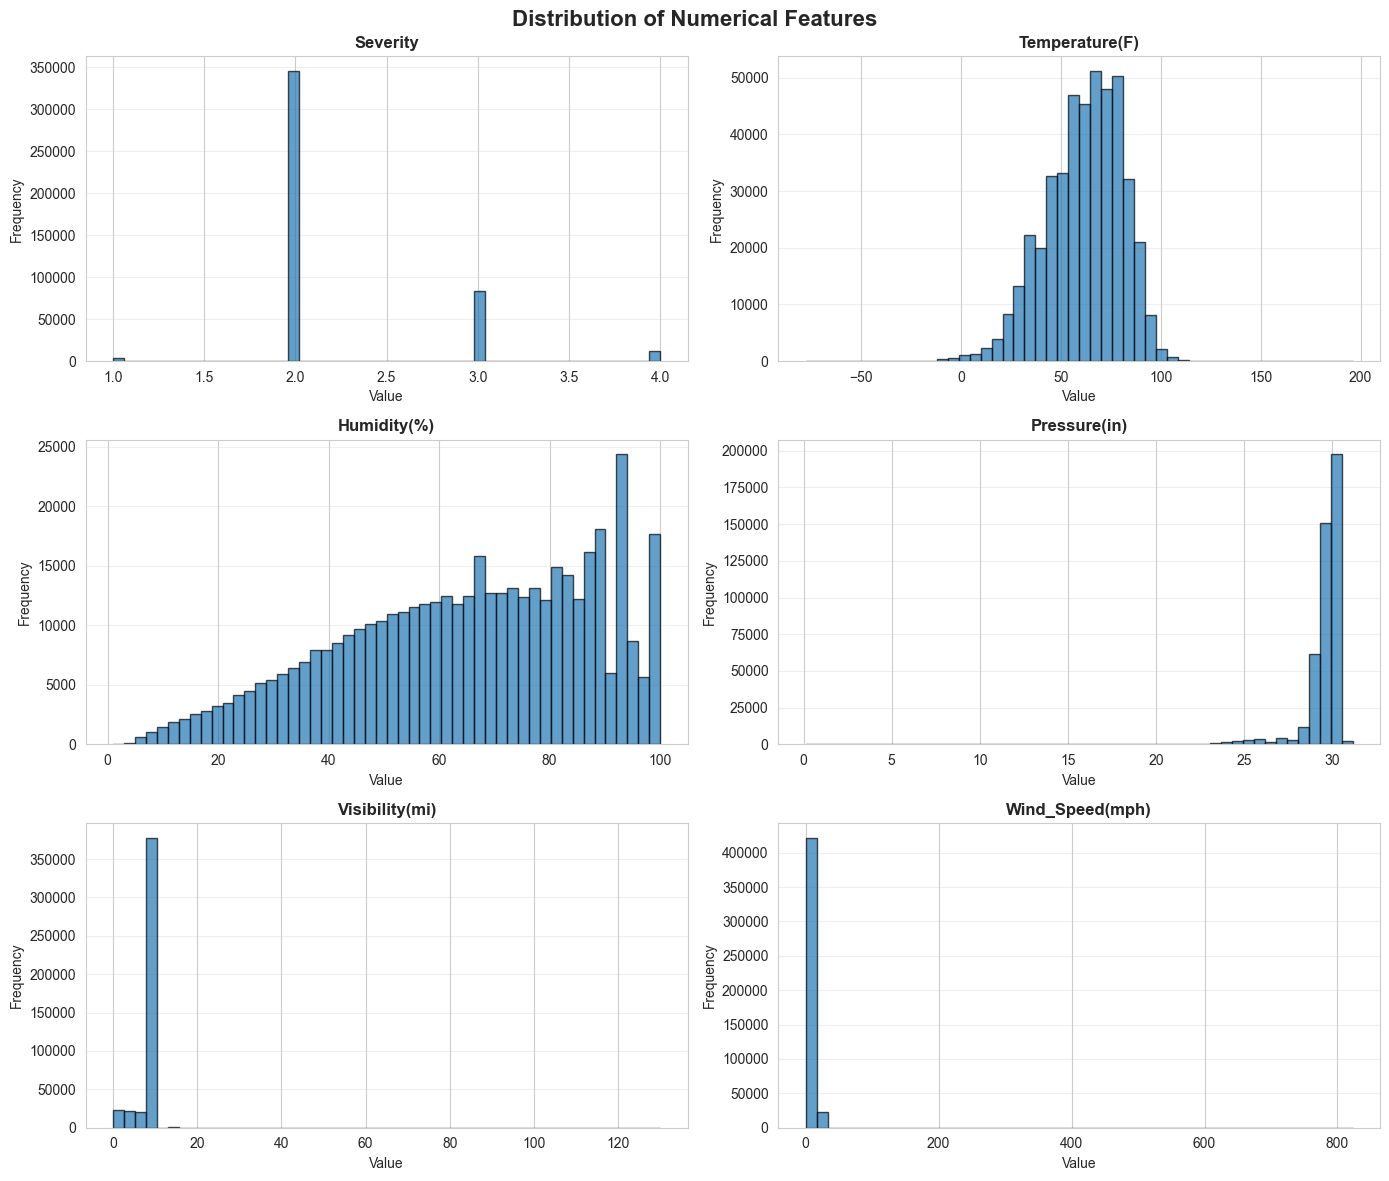

In [76]:
## 2. Numerical Features - Distributions

import os

# Create directory structure
os.makedirs('results/figures/univariate', exist_ok=True)
os.makedirs('results/figures/bivariate', exist_ok=True)

# Create histograms for main numerical features
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

numerical_to_plot = [
    'Severity', 'Temperature(F)', 'Humidity(%)', 
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)'
]

for idx, col in enumerate(numerical_to_plot):
    ax = axes[idx // 2, idx % 2]
    df_clean[col].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}', fontweight='bold')

    ax.set_xlabel('Value')

    ax.set_ylabel('Frequency')

    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/univariate/01_numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

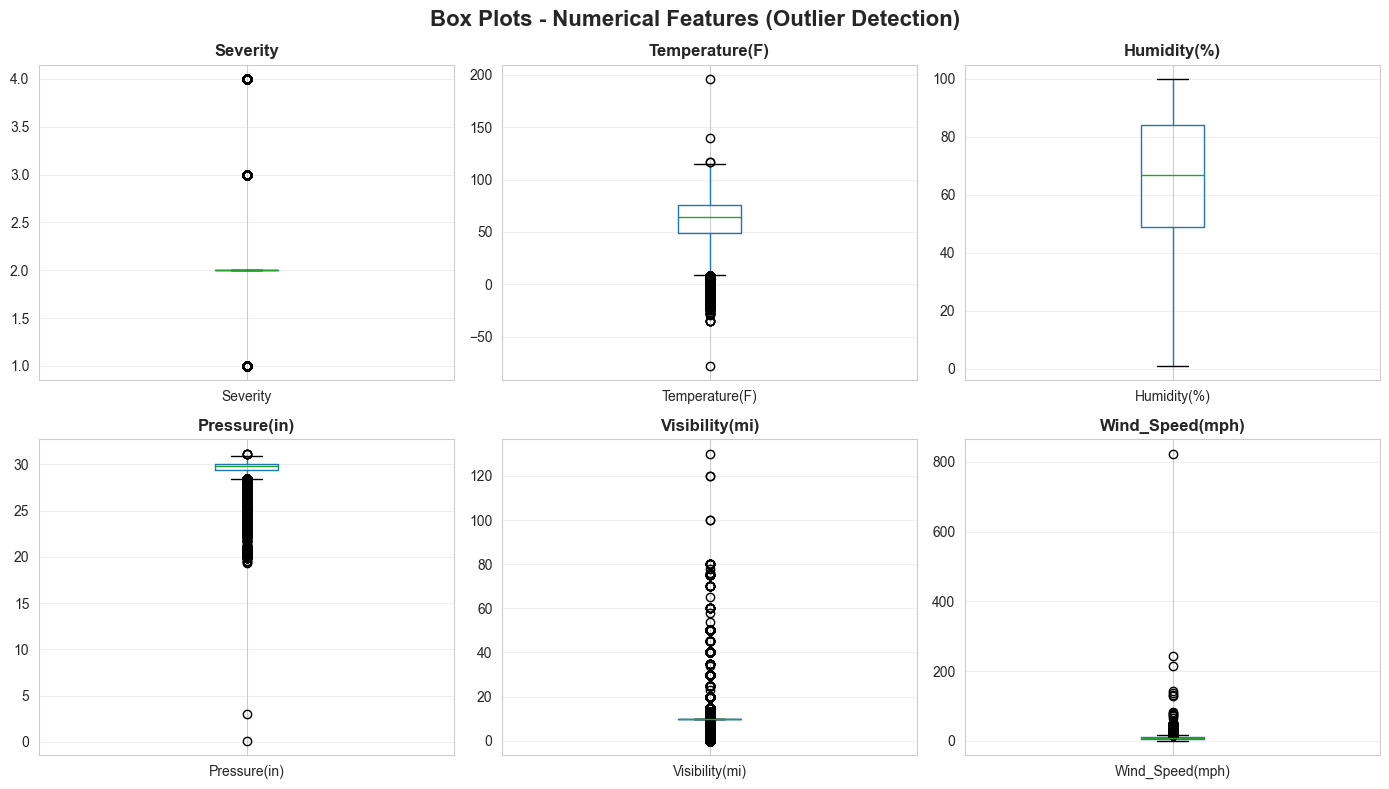

In [77]:
## 3. Numerical Features - Box Plots (Outlier Detection)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Box Plots - Numerical Features (Outlier Detection)', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_to_plot):
    ax = axes[idx // 3, idx % 3]
    df_clean[[col]].boxplot(ax=ax)
    ax.set_title(f'{col}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/univariate/02_boxplots_outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

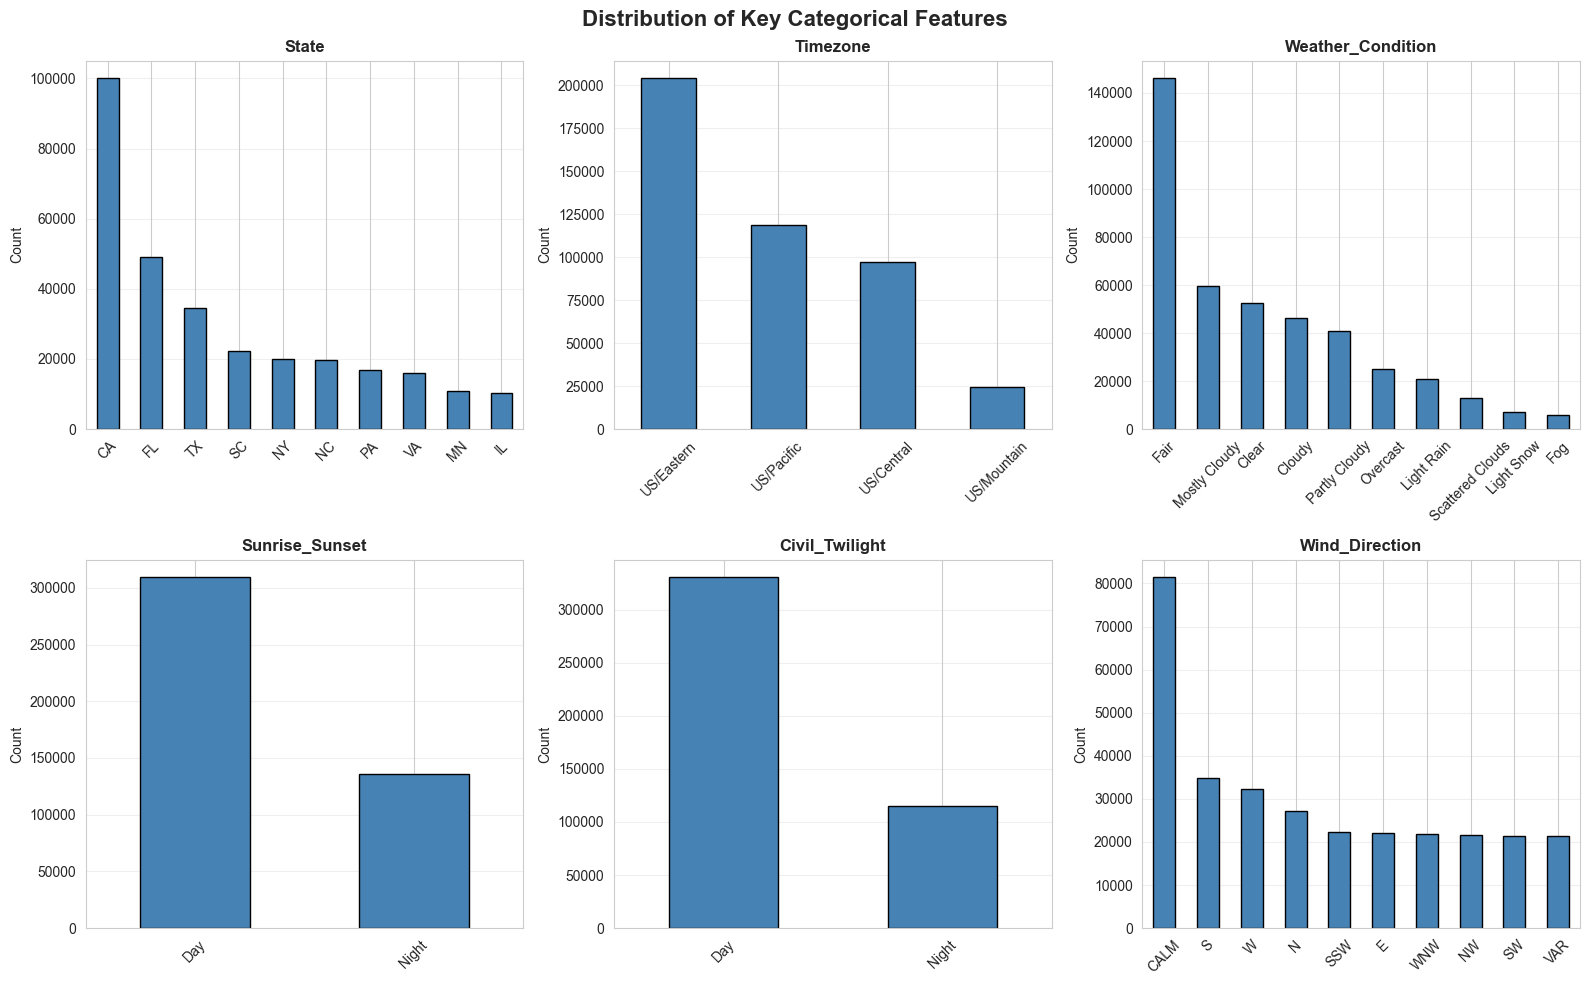

In [78]:
## 5. Categorical Features - Visual Distribution

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Key Categorical Features', fontsize=16, fontweight='bold')

categorical_to_plot = ['State', 'Timezone', 'Weather_Condition', 'Sunrise_Sunset', 
                       'Civil_Twilight', 'Wind_Direction']

for idx, col in enumerate(categorical_to_plot):
    ax = axes[idx // 3, idx % 3]
    top_values = df_clean[col].value_counts().head(10)
    top_values.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/univariate/03_categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()


TARGET VARIABLE - SEVERITY ANALYSIS

Severity Distribution:
  Level 1:   4,226 accidents (  0.9%)
  Level 2: 345,878 accidents ( 77.7%)
  Level 3:  83,412 accidents ( 18.7%)
  Level 4:  11,557 accidents (  2.6%)

Severity Statistics:
  Mean: 2.230
  Median: 2.000
  Mode: 2
  Std Dev: 0.498


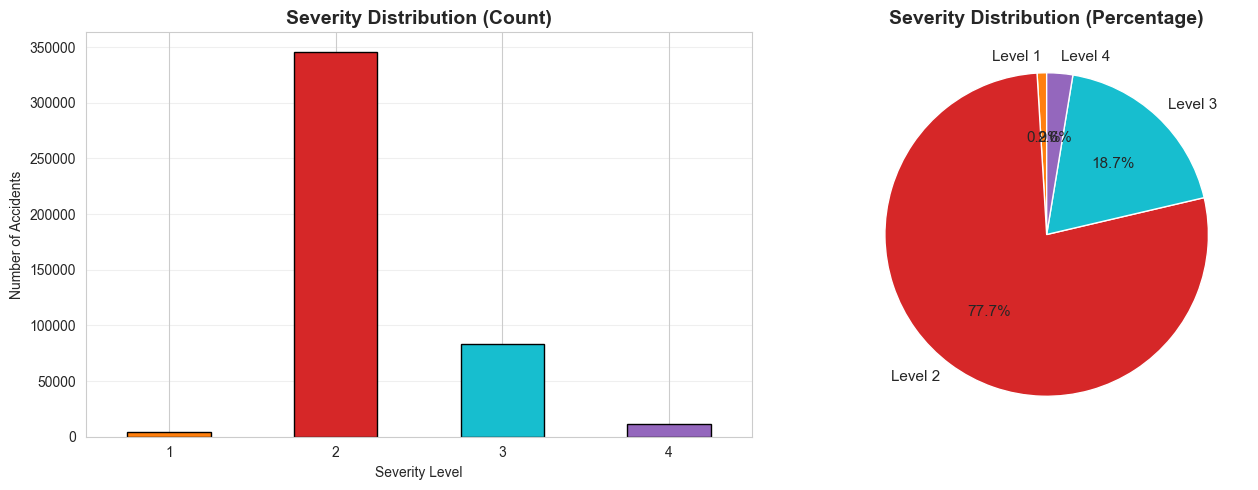

In [79]:
## 6. Target Variable - Severity Distribution

print("\n" + "=" * 80)
print("TARGET VARIABLE - SEVERITY ANALYSIS")
print("=" * 80)

severity_counts = df_clean['Severity'].value_counts().sort_index()
severity_pct = df_clean['Severity'].value_counts(normalize=True).sort_index() * 100

print("\nSeverity Distribution:")
for level in sorted(df_clean['Severity'].unique()):
    count = severity_counts[level]
    pct = severity_pct[level]
    print(f"  Level {int(level)}: {count:>7,} accidents ({pct:>5.1f}%)")

print(f"\nSeverity Statistics:")
print(f"  Mean: {df_clean['Severity'].mean():.3f}")
print(f"  Median: {df_clean['Severity'].median():.3f}")
print(f"  Mode: {df_clean['Severity'].mode()[0]:.0f}")
print(f"  Std Dev: {df_clean['Severity'].std():.3f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
severity_counts.plot(kind='bar', ax=ax1, color=['#ff7f0e', '#d62728', '#17becf', '#9467bd'], edgecolor='black')
ax1.set_title('Severity Distribution (Count)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Severity Level')
ax1.set_ylabel('Number of Accidents')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.grid(axis='y', alpha=0.3)

# Pie chart
colors = ['#ff7f0e', '#d62728', '#17becf', '#9467bd']
ax2.pie(severity_counts, labels=[f'Level {int(i)}' for i in severity_counts.index], 
        autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 11})
ax2.set_title('Severity Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/univariate/04_severity_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


BOOLEAN FEATURES (POINTS OF INTEREST) - PREVALENCE ANALYSIS
Amenity             :   5,563 (  1.2%)
Bump                :     184 (  0.0%)
Crossing            :  51,660 ( 11.6%)
Give_Way            :   2,155 (  0.5%)
Junction            :  33,319 (  7.5%)
No_Exit             :   1,126 (  0.3%)
Railway             :   3,889 (  0.9%)
Roundabout          :      10 (  0.0%)
Station             :  11,585 (  2.6%)
Stop                :  12,525 (  2.8%)
Traffic_Calming     :     417 (  0.1%)
Traffic_Signal      :  69,730 ( 15.7%)
Turning_Loop        :       0 (  0.0%)


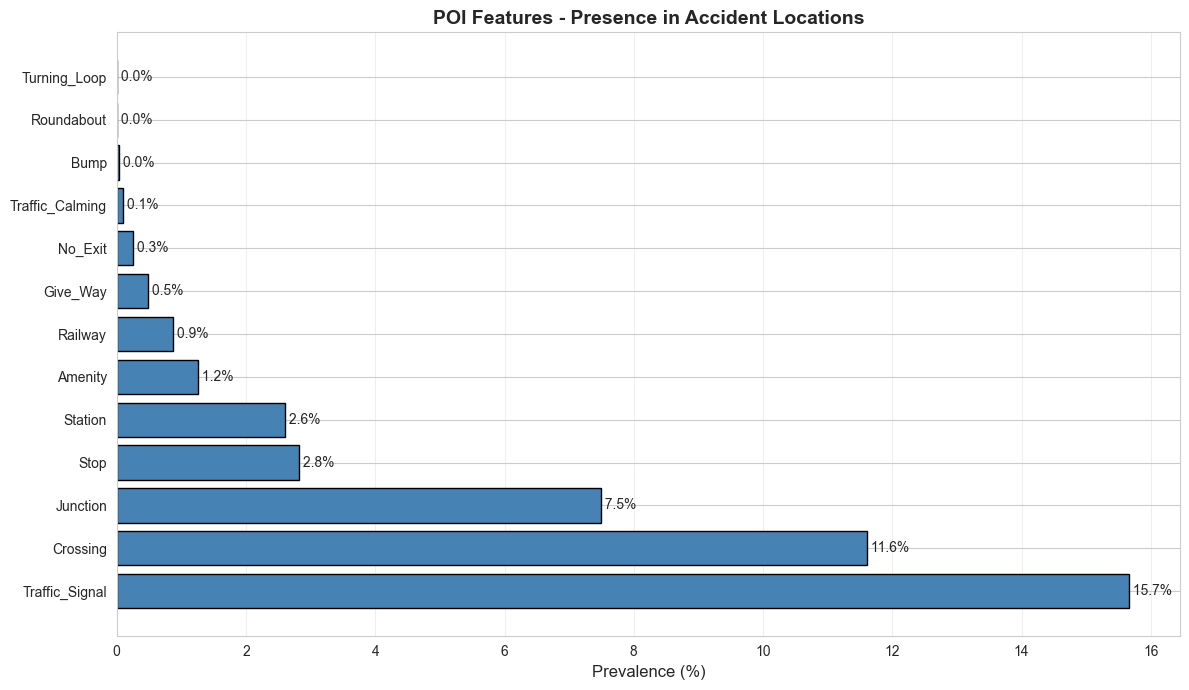

In [80]:
## 7. Boolean Features (POI Indicators) - Prevalence Analysis

poi_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 
                'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 
                'Traffic_Signal', 'Turning_Loop']

print("\n" + "=" * 80)
print("BOOLEAN FEATURES (POINTS OF INTEREST) - PREVALENCE ANALYSIS")
print("=" * 80)

poi_prevalence = {}
for feature in poi_features:
    true_count = (df_clean[feature] == True).sum()
    true_pct = (true_count / len(df_clean)) * 100
    poi_prevalence[feature] = true_pct
    print(f"{feature:20s}: {true_count:>7,} ({true_pct:>5.1f}%)")

# Visualization
fig, ax = plt.subplots(figsize=(12, 7))

poi_sorted = dict(sorted(poi_prevalence.items(), key=lambda x: x[1], reverse=True))
features = list(poi_sorted.keys())
prevalence = list(poi_sorted.values())

bars = ax.barh(features, prevalence, color='steelblue', edgecolor='black')
ax.set_xlabel('Prevalence (%)', fontsize=12)
ax.set_title('POI Features - Presence in Accident Locations', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, prevalence)):
    ax.text(val, i, f' {val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('results/figures/univariate/05_poi_features_prevalence.png', dpi=300, bbox_inches='tight')
plt.show()

In [81]:
## 8. Skewness and Kurtosis Analysis

from scipy import stats

print("\n" + "=" * 80)
print("SKEWNESS & KURTOSIS ANALYSIS - NUMERICAL FEATURES")
print("=" * 80)
print(f"{'Feature':<20} {'Skewness':>12} {'Kurtosis':>12} {'Distribution':>20}")
print("-" * 80)

for col in numerical_to_plot:
    skew = stats.skew(df_clean[col])
    kurt = stats.kurtosis(df_clean[col])
    
    if abs(skew) < 0.5:
        dist = "Fairly Symmetric"
    elif skew > 0:
        dist = "Right-skewed"
    else:
        dist = "Left-skewed"
    
    print(f"{col:<20} {skew:>12.3f} {kurt:>12.3f} {dist:>20}")

print("\nNote: Skewness values:")
print("  -0.5 to 0.5: Fairly symmetric")
print("  0.5 to 1 or -1 to -0.5: Moderately skewed")
print("  > 1 or < -1: Highly skewed")


SKEWNESS & KURTOSIS ANALYSIS - NUMERICAL FEATURES
Feature                  Skewness     Kurtosis         Distribution
--------------------------------------------------------------------------------
Severity                    1.641        2.608         Right-skewed
Temperature(F)             -0.510        0.015          Left-skewed
Humidity(%)                -0.410       -0.695     Fairly Symmetric
Pressure(in)               -3.814       20.423          Left-skewed
Visibility(mi)              3.011       99.932         Right-skewed
Wind_Speed(mph)             9.692     1333.342         Right-skewed

Note: Skewness values:
  -0.5 to 0.5: Fairly symmetric
  0.5 to 1 or -1 to -0.5: Moderately skewed
  > 1 or < -1: Highly skewed


In [14]:
# Check Wind_Speed outliers
print("Wind_Speed Statistics:")
print(df_clean['Wind_Speed(mph)'].describe())
print(f"\nMax value: {df_clean['Wind_Speed(mph)'].max()}")
print(f"99th percentile: {df_clean['Wind_Speed(mph)'].quantile(0.99)}")

# Check Pressure outliers
print("\n\nPressure Statistics:")
print(df_clean['Pressure(in)'].describe())
print(f"\nMin value: {df_clean['Pressure(in)'].min()}")
print(f"1st percentile: {df_clean['Pressure(in)'].quantile(0.01)}")

Wind_Speed Statistics:
count    445073.000000
mean          7.647183
std           5.241436
min           0.000000
25%           5.000000
50%           7.000000
75%          10.000000
max         822.800000
Name: Wind_Speed(mph), dtype: float64

Max value: 822.8
99th percentile: 23.0


Pressure Statistics:
count    445073.000000
mean         29.557549
std           0.988267
min           0.120000
25%          29.390000
50%          29.870000
75%          30.040000
max          31.150000
Name: Pressure(in), dtype: float64

Min value: 0.12
1st percentile: 24.63


## Temporal Features Extraction

In [13]:
# Extract temporal features from Start_Time
df_clean['Hour'] = df_clean['Start_Time'].dt.hour
df_clean['Day_of_Week'] = df_clean['Start_Time'].dt.day_name()
df_clean['Day_of_Week_Num'] = df_clean['Start_Time'].dt.dayofweek  # Monday=0, Sunday=6
df_clean['Month'] = df_clean['Start_Time'].dt.month
df_clean['Month_Name'] = df_clean['Start_Time'].dt.month_name()
df_clean['Day'] = df_clean['Start_Time'].dt.day

# Create season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_clean['Season'] = df_clean['Month'].apply(get_season)

# Create time of day categories
def get_time_period(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df_clean['Time_Period'] = df_clean['Hour'].apply(get_time_period)

# Create weekend flag
df_clean['Is_Weekend'] = df_clean['Day_of_Week_Num'].isin([5, 6]).astype(int)




# Bivariate Analysis

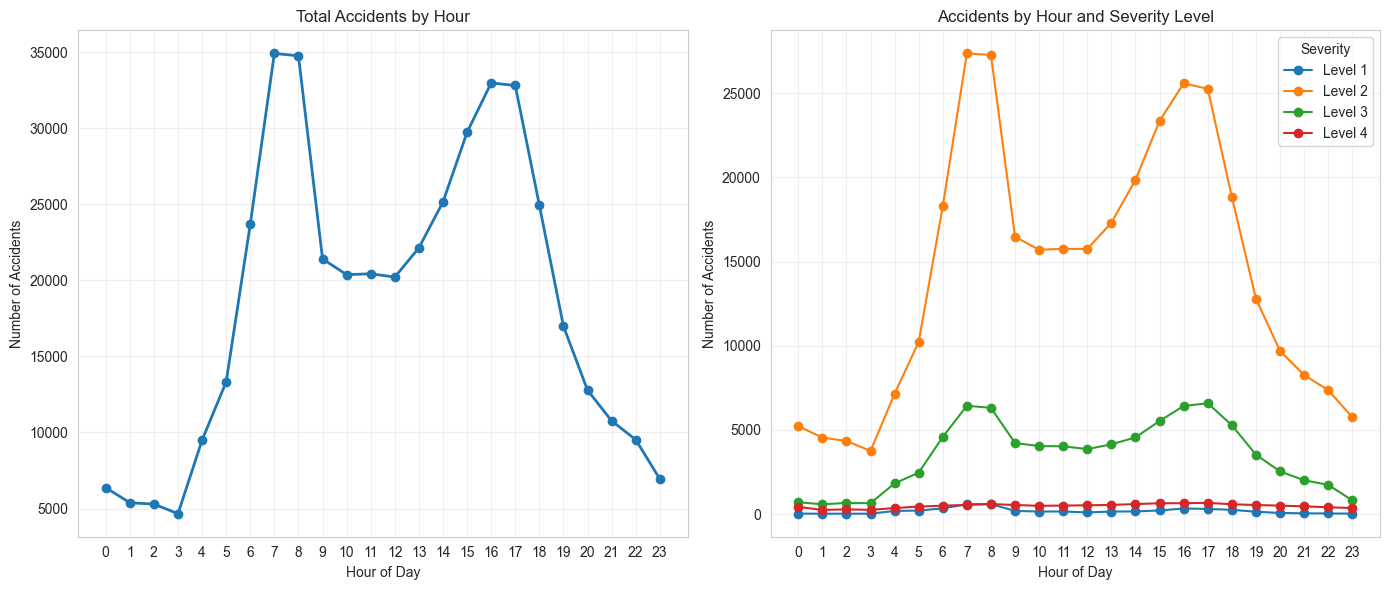

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# 1. Accidents by Hour and Severity
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Count of accidents by hour
hour_counts = df_clean.groupby('Hour').size()
plt.plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.title('Total Accidents by Hour')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Severity distribution by hour
severity_by_hour = df_clean.groupby(['Hour', 'Severity']).size().unstack(fill_value=0)
severity_by_hour.plot(kind='line', marker='o', ax=plt.gca())
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.title('Accidents by Hour and Severity Level')
plt.legend(title='Severity', labels=['Level 1', 'Level 2', 'Level 3', 'Level 4'])
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.savefig('results/figures/bivariate/01_accidents_by_hour_and_severity.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

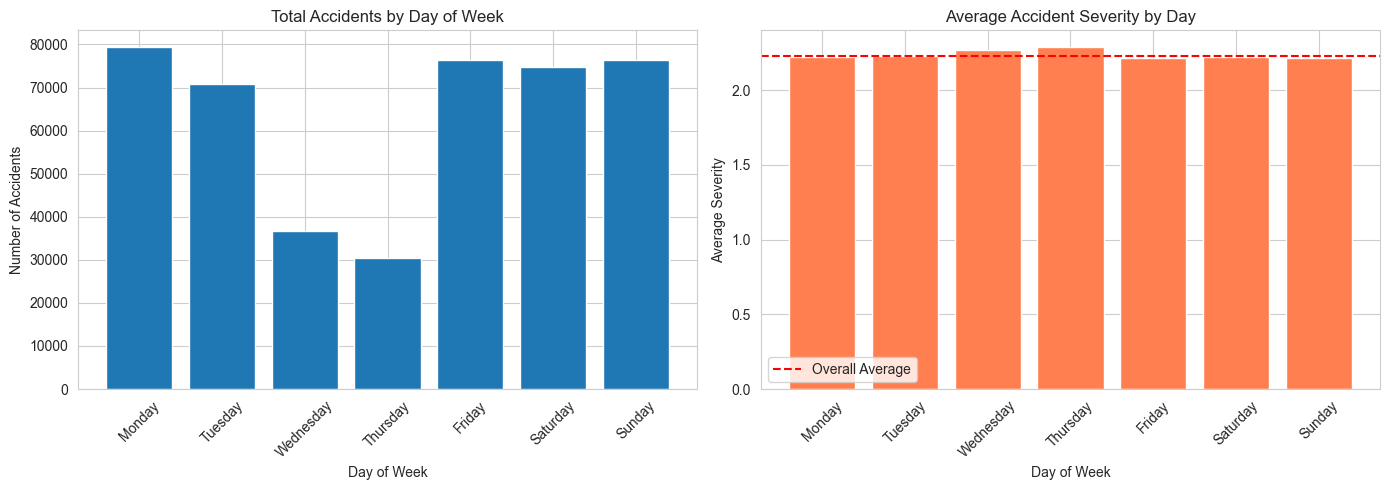

In [85]:
# 2. Accidents by Day of Week
plt.figure(figsize=(14, 5))

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.subplot(1, 2, 1)
# Total by day
day_counts = df_clean['Day_of_Week'].value_counts().sort_index()
plt.bar(range(7), day_counts.values)
plt.xlabel('Day of Week')
plt.ylabel('Number of Accidents')
plt.title('Total Accidents by Day of Week')
plt.xticks(range(7), day_names, rotation=45)

plt.subplot(1, 2, 2)
# Average severity by day
avg_severity_by_day = df_clean.groupby('Day_of_Week')['Severity'].mean()
plt.bar(range(7), avg_severity_by_day.values, color='coral')
plt.xlabel('Day of Week')
plt.ylabel('Average Severity')
plt.title('Average Accident Severity by Day')
plt.xticks(range(7), day_names, rotation=45)
plt.axhline(y=df_clean['Severity'].mean(), color='red', linestyle='--', label='Overall Average')
plt.legend()
plt.savefig('results/figures/bivariate/02_accidents_by_day_of_week.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

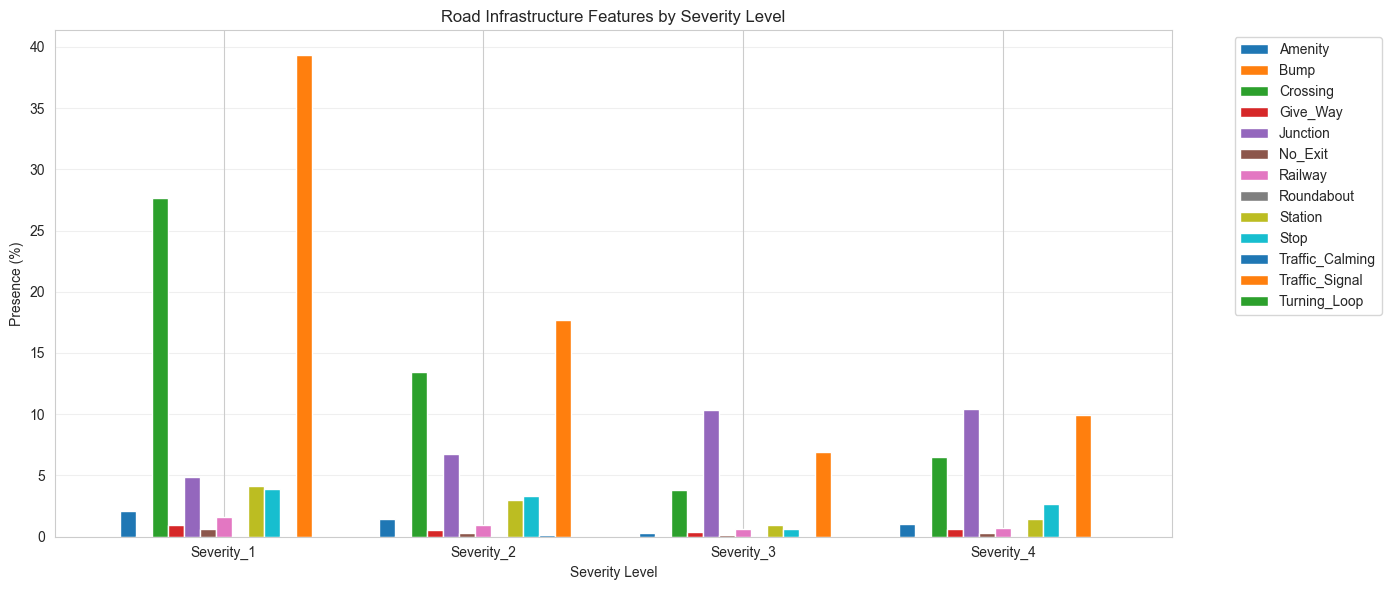


POI presence by severity (%):
             Amenity      Bump   Crossing  Give_Way   Junction   No_Exit  \
Severity_1  2.058684  0.047326  27.614766  0.922858   4.874586  0.591576   
Severity_2  1.469882  0.045681  13.469200  0.507693   6.739371  0.275531   
Severity_3  0.329689  0.023977   3.787225  0.350070  10.304273  0.134273   
Severity_4  1.012373  0.034611   6.463615  0.588388  10.452540  0.311500   

             Railway  Roundabout   Station      Stop  Traffic_Calming  \
Severity_1  1.632750    0.000000  4.117369  3.880738         0.070989   
Severity_2  0.925182    0.002891  3.022164  3.337015         0.103505   
Severity_3  0.643792    0.000000  0.954299  0.618616         0.057546   
Severity_4  0.718179    0.000000  1.401748  2.621788         0.069222   

            Traffic_Signal  Turning_Loop  
Severity_1       39.375296           0.0  
Severity_2       17.686583           0.0  
Severity_3        6.888697           0.0  
Severity_4        9.916068           0.0  


In [86]:
# POI features vs Severity
poi_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 
                'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 
                'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

# Calculate percentage of each POI for each severity level
poi_severity = pd.DataFrame()
for severity in [1, 2, 3, 4]:
    poi_severity[f'Severity_{severity}'] = df_clean[df_clean['Severity'] == severity][poi_features].mean() * 100

# Plot
plt.figure(figsize=(14, 6))
poi_severity.T.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.xlabel('Severity Level')
plt.ylabel('Presence (%)')
plt.title('Road Infrastructure Features by Severity Level')
plt.legend(poi_features, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('results/figures/bivariate/03_poi_presence_by_severity.png', dpi=300, bbox_inches='tight')  
plt.show()

print("\nPOI presence by severity (%):")
print(poi_severity.T)

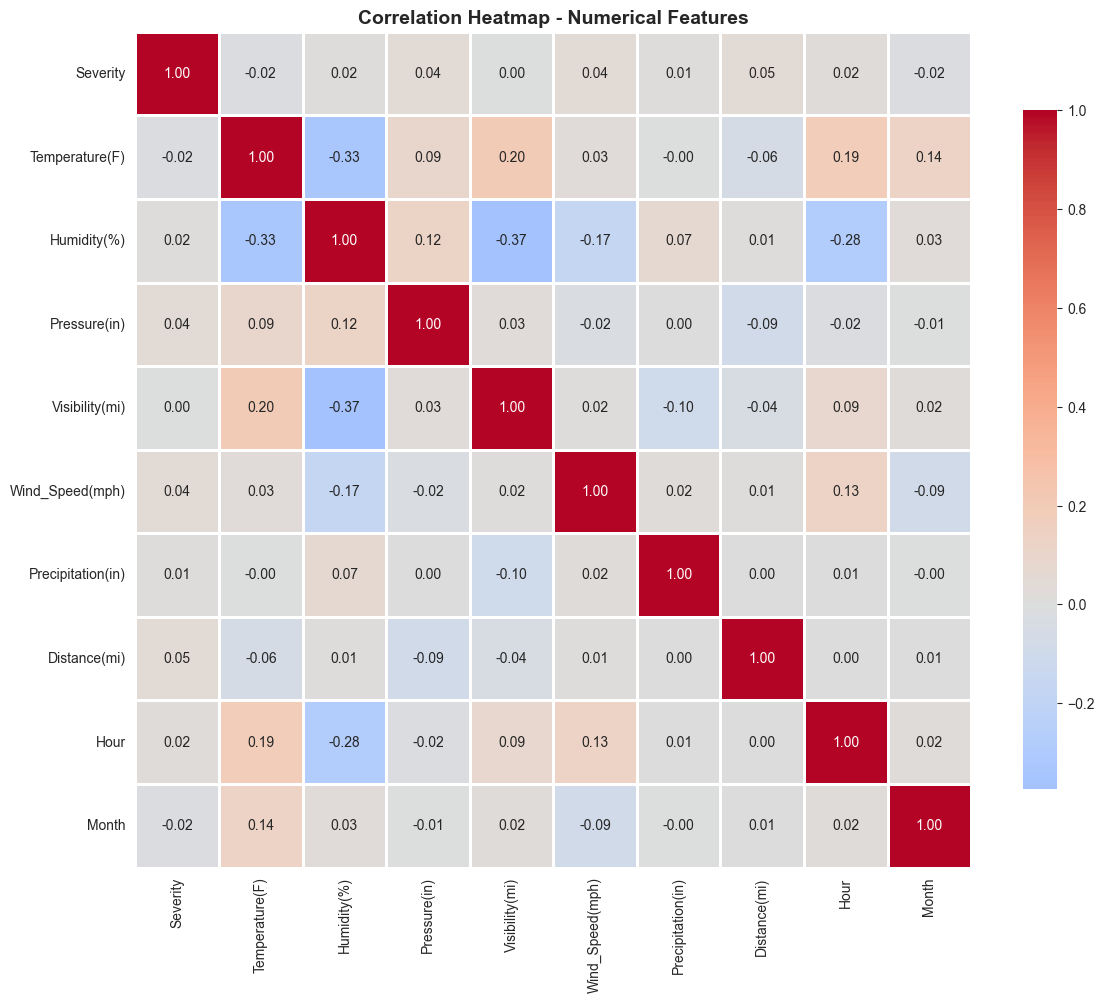


Correlations with Severity (sorted by absolute value):
Severity             1.000000
Distance(mi)         0.047071
Pressure(in)         0.043856
Wind_Speed(mph)      0.041368
Hour                 0.020110
Humidity(%)          0.016277
Precipitation(in)    0.010337
Visibility(mi)       0.000188
Month               -0.017072
Temperature(F)      -0.018379
Name: Severity, dtype: float64


In [87]:
# Select numerical features for correlation
numerical_features = ['Severity', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
                      'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
                      'Distance(mi)', 'Hour', 'Month']

# Calculate correlation matrix
correlation_matrix = df_clean[numerical_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/bivariate/04_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top correlations with Severity
print("\nCorrelations with Severity (sorted by absolute value):")
severity_corr = correlation_matrix['Severity'].sort_values(ascending=False)
print(severity_corr)

<Figure size 1400x600 with 0 Axes>

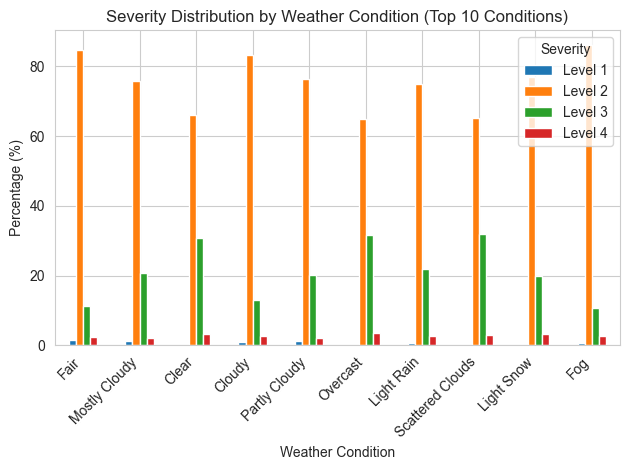


Severity distribution by weather condition (%):
Severity                  1          2          3         4
Weather_Condition                                          
Fair               1.477529  84.745195  11.420070  2.357206
Mostly Cloudy      1.175442  75.948005  20.660198  2.216355
Clear              0.045858  65.921467  30.772905  3.259769
Cloudy             1.065364  83.186622  13.074920  2.673095
Partly Cloudy      1.143568  76.487370  20.157515  2.211548
Overcast           0.028117  64.813625  31.507069  3.651189
Light Rain         0.727641  74.937355  21.781033  2.553971
Scattered Clouds   0.030701  65.116279  31.921099  2.931921
Light Snow         0.083496  76.829947  19.774562  3.311996
Fog                0.574513  86.020195  10.776462  2.628830


In [88]:
# Weather Condition (categorical) vs Severity
weather_severity = pd.crosstab(df_clean['Weather_Condition'], df_clean['Severity'], 
                                normalize='index') * 100

# Get top 10 most common weather conditions
top_weather = df_clean['Weather_Condition'].value_counts().head(10).index
weather_severity_top = weather_severity.loc[top_weather]

# Plot
plt.figure(figsize=(14, 6))
weather_severity_top.plot(kind='bar', stacked=False)
plt.xlabel('Weather Condition')
plt.ylabel('Percentage (%)')
plt.title('Severity Distribution by Weather Condition (Top 10 Conditions)')
plt.legend(title='Severity', labels=['Level 1', 'Level 2', 'Level 3', 'Level 4'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('results/figures/bivariate/05_severity_by_weather_condition.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSeverity distribution by weather condition (%):")
print(weather_severity_top)

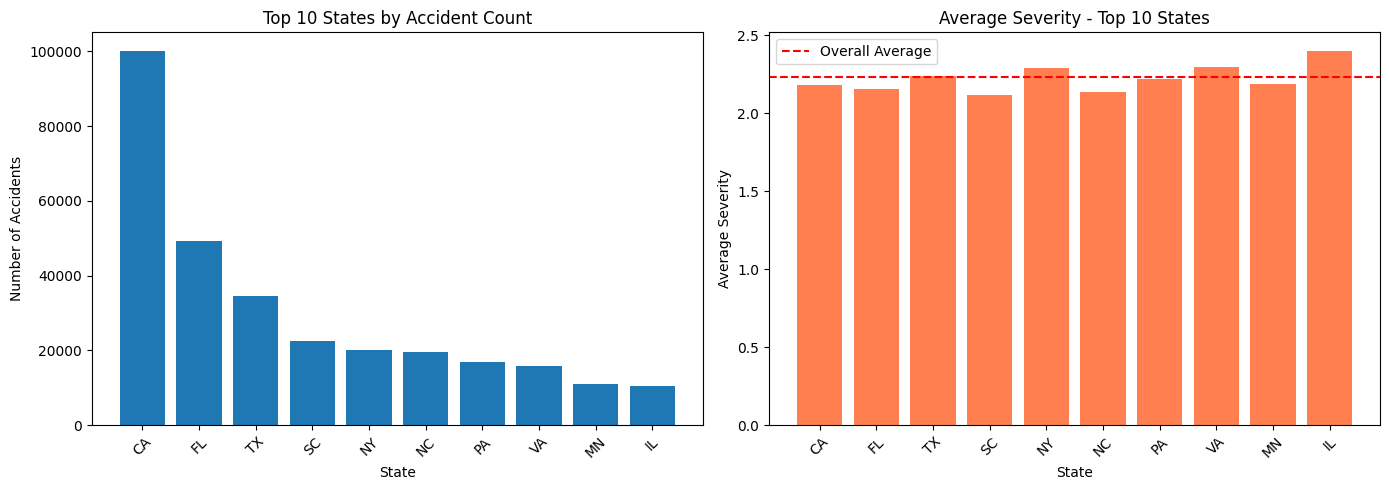


Top 10 States:
           mean   count
State                  
CA     2.183313  100102
FL     2.156935   49167
TX     2.235473   34522
SC     2.119764   22369
NY     2.286720   20030
NC     2.133089   19656
PA     2.216619   16776
VA     2.299114   15917
MN     2.185610   10910
IL     2.398714   10421


In [15]:
# Geographic analysis - State vs Severity
state_severity = df_clean.groupby('State')['Severity'].agg(['mean', 'count']).sort_values('count', ascending=False)
top_states = state_severity.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 states by accident count
axes[0].bar(range(10), top_states['count'].values)
axes[0].set_xlabel('State')
axes[0].set_ylabel('Number of Accidents')
axes[0].set_title('Top 10 States by Accident Count')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(top_states.index, rotation=45)

# Average severity by top 10 states
axes[1].bar(range(10), top_states['mean'].values, color='coral')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Average Severity')
axes[1].set_title('Average Severity - Top 10 States')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(top_states.index, rotation=45)
axes[1].axhline(y=df_clean['Severity'].mean(), color='red', linestyle='--', label='Overall Average')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/figures/bivariate/06_severity_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 States:")
print(top_states)

## Feature Engineering

In [16]:

print("="*80)
print("STEP 1: FEATURE ENGINEERING")
print("="*80)

# Make a copy to preserve original
df_features = df_clean.copy()

# 1. Rush Hour Flag (binary: 1 if rush hour, 0 otherwise)
# Based on EDA: peaks at 7-8 AM and 3-5 PM
df_features['Rush_Hour'] = df_features['Hour'].apply(
    lambda x: 1 if x in [7, 8, 16, 17] else 0
)

# 5. High Risk Junction Flag (Junction without traffic control)
df_features['High_Risk_Junction'] = (
    (df_features['Junction'] == True) & 
    (df_features['Traffic_Signal'] == False)
).astype(int)

print(f"Rush_Hour distribution:\n{df_features['Rush_Hour'].value_counts()}")
print(f"High_Risk_Junction distribution:\n{df_features['High_Risk_Junction'].value_counts()}")

STEP 1: FEATURE ENGINEERING
Rush_Hour distribution:
Rush_Hour
0    309606
1    135467
Name: count, dtype: int64
High_Risk_Junction distribution:
High_Risk_Junction
0    412343
1     32730
Name: count, dtype: int64


In [17]:
print("\n" + "="*80)
print("STEP 2: FEATURE SELECTION")
print("="*80)

# Columns to drop (not needed for modeling)
columns_to_drop = [
    # Original datetime columns (already extracted features from them)
    'Start_Time', 'End_Time', 'Weather_Timestamp',
    
    # Metadata columns (not predictive)
    'ID', 'Source', 'Description',
    
    # Geographic text fields (will use State, drop City due to high cardinality)
    'Street', 'City', 'County', 'Zipcode', 'Country',
    
    # Airport code (not useful)
    'Airport_Code',
    
    # Timezone (redundant with geographic location)
    'Timezone',
    
    # Twilight features (redundant with Hour and Sunrise_Sunset)
    'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
    
    # Start/End coordinates (keep as is, don't drop - useful for modeling)
    # 'Start_Lat', 'Start_Lng'  # KEEP these

    'Month_Name',  # Drop Month_Name since we have Month numeric and Season categorical,
    'Day_of_Week'  # Drop Day_of_Week since we have Day_of_Week_Num and Is_Weekend
]

# Drop columns
df_features = df_features.drop(columns=columns_to_drop)

print(f"\nColumns dropped: {len(columns_to_drop)}")
print(f"Remaining columns: {df_features.shape[1]}")
print(f"\nRemaining feature list:")
print(df_features.columns.tolist())


STEP 2: FEATURE SELECTION

Columns dropped: 18
Remaining columns: 36

Remaining feature list:
['Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'State', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Hour', 'Day_of_Week_Num', 'Month', 'Day', 'Season', 'Time_Period', 'Is_Weekend', 'Rush_Hour', 'High_Risk_Junction']


In [18]:
#ENCODING CATEGORICAL VARIABLES
# Separate target variable before encoding
y = df_features['Severity']
X = df_features.drop(columns=['Severity'])

print(f"Target variable (y) shape: {y.shape}")
print(f"Features (X) shape before encoding: {X.shape}")

# Identify categorical columns
categorical_columns = X.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"\nCategorical columns to encode: {categorical_columns}")

# 1. Weather_Condition - One-hot encode
# Get top 10 weather conditions, group rest as "Other"
top_weather = X['Weather_Condition'].value_counts().head(10).index.tolist()
X['Weather_Condition'] = X['Weather_Condition'].apply(
    lambda x: x if x in top_weather else 'Other'
)

# 2. State - One-hot encode
# Get top 15 states, group rest as "Other"
top_states = X['State'].value_counts().head(15).index.tolist()
X['State'] = X['State'].apply(
    lambda x: x if x in top_states else 'Other'
)

# 3. Wind_Direction - One-hot encode (already standardized)

# 4. Sunrise_Sunset - Binary encode (Day=1, Night=0)
X['Sunrise_Sunset'] = X['Sunrise_Sunset'].map({'Day': 1, 'Night': 0})

# Apply one-hot encoding
categorical_to_encode = ['Weather_Condition', 'State', 'Wind_Direction', 'Season','Time_Period']

X_encoded = pd.get_dummies(X, columns=categorical_to_encode, drop_first=True, dtype=int)

print(f"\nFeatures (X) shape after encoding: {X_encoded.shape}")
print(f"New feature count: {X_encoded.shape[1]}")



Target variable (y) shape: (445073,)
Features (X) shape before encoding: (445073, 35)

Categorical columns to encode: ['State', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Season', 'Time_Period']

Features (X) shape after encoding: (445073, 78)
New feature count: 78


## TRAIN AND TEST SPLIT


In [19]:
from sklearn.model_selection import train_test_split
print("\n" + "="*80)
print("STEP 4: TRAIN-TEST SPLIT")
print("="*80)   

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)


print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")

# Verify class distribution maintained
print("\nClass distribution in original data:")
print(y.value_counts(normalize=True).sort_index())

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True).sort_index())

print("\n✓ Stratification successful - distributions match!")


STEP 4: TRAIN-TEST SPLIT
Training set size: 356058 (80.0%)
Test set size: 89015 (20.0%)

Class distribution in original data:
Severity
1    0.009495
2    0.777126
3    0.187412
4    0.025967
Name: proportion, dtype: float64

Class distribution in training set:
Severity
1    0.009496
2    0.777126
3    0.187410
4    0.025968
Name: proportion, dtype: float64

Class distribution in test set:
Severity
1    0.009493
2    0.777127
3    0.187418
4    0.025962
Name: proportion, dtype: float64

✓ Stratification successful - distributions match!



STEP 3: LOG TRANSFORMATIONS
Created: Wind_Speed_log
Created: Visibility_log
Created: Distance_log
Created: Precipitation_log


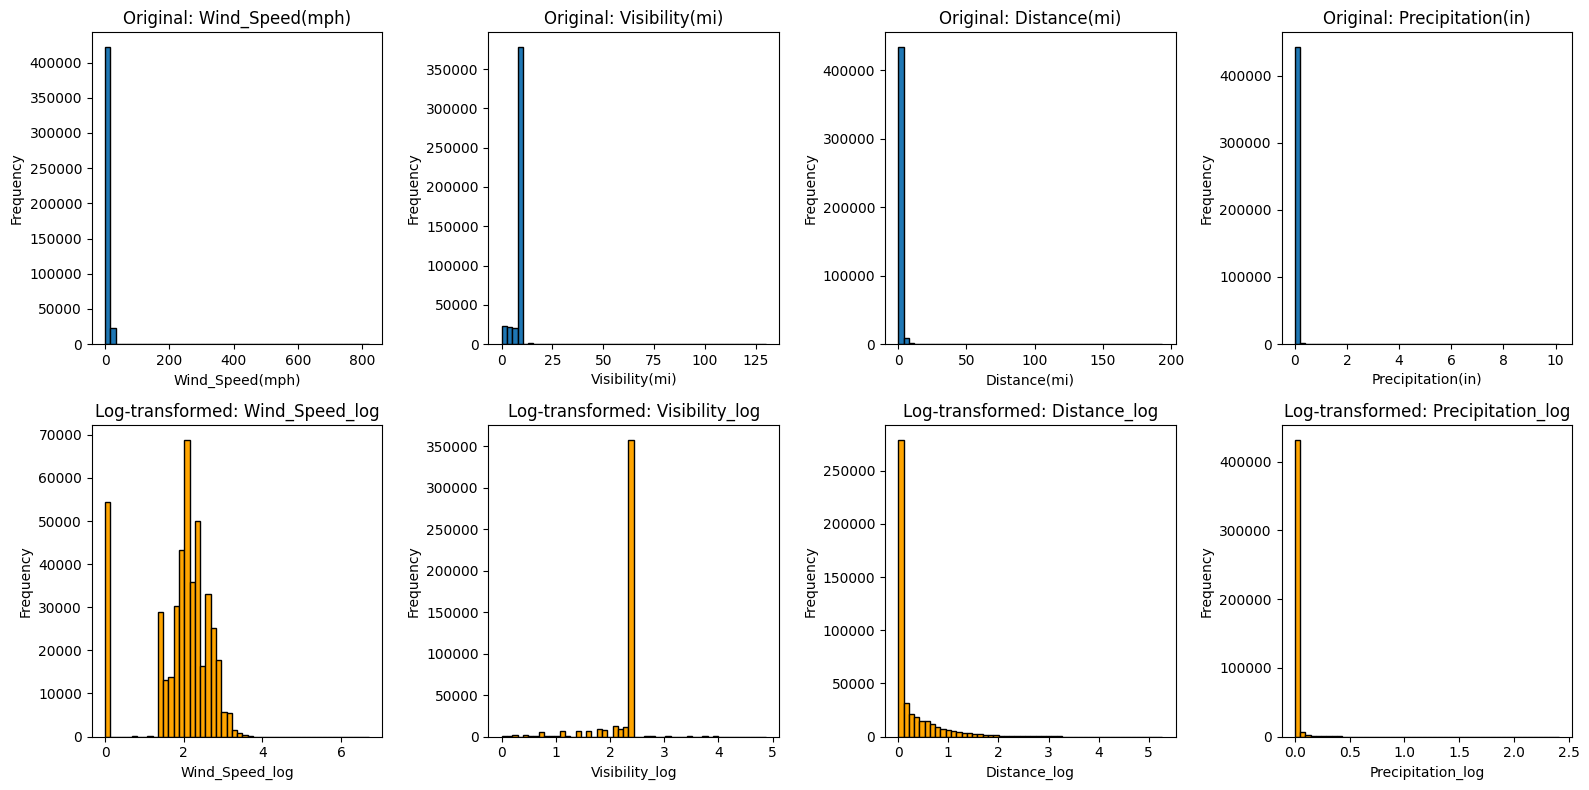


Dataset shape after transformations: (445073, 40)


In [20]:
print("\n" + "="*80)
print("STEP 3: LOG TRANSFORMATIONS")
print("="*80)

# Features with high skewness (from EDA)
skewed_features = ['Wind_Speed(mph)', 'Visibility(mi)', 'Distance(mi)', 'Precipitation(in)']

# Apply log1p transformation (log(1 + x) to handle zeros)
for feature in skewed_features:
    if feature in df_features.columns:
        new_feature_name = f'{feature.split("(")[0]}_log'
        df_features[new_feature_name] = np.log1p(df_features[feature])
        print(f"Created: {new_feature_name}")

# Compare distributions before/after (optional visualization)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, feature in enumerate(skewed_features):
    if feature in df_features.columns:
        # Original
        axes[0, i].hist(df_features[feature], bins=50, edgecolor='black')
        axes[0, i].set_title(f'Original: {feature}')
        axes[0, i].set_xlabel(feature)
        axes[0, i].set_ylabel('Frequency')
        
        # Log-transformed
        log_feature = f'{feature.split("(")[0]}_log'
        axes[1, i].hist(df_features[log_feature], bins=50, edgecolor='black', color='orange')
        axes[1, i].set_title(f'Log-transformed: {log_feature}')
        axes[1, i].set_xlabel(log_feature)
        axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('results/figures/bivariate/07_log_transformations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nDataset shape after transformations: {df_features.shape}")


In [22]:
df_features = df_features.drop(columns=skewed_features)
print(f"Dataset shape after dropping original skewed features: {df_features.shape}")

Dataset shape after dropping original skewed features: (445073, 36)


##  SCALING NUMERIC COLUMNS

In [25]:
from sklearn.preprocessing import StandardScaler

print("\n" + "="*80)
print("STEP 6: FEATURE SCALING")
print("="*80)

# Identify numerical columns (exclude binary 0/1 features)
binary_columns = [col for col in X_train.columns if X_train[col].nunique() == 2 and set(X_train[col].unique()).issubset({0, 1})]
numerical_columns = [col for col in X_train.columns if col not in binary_columns]

print(f"Binary features (will NOT scale): {len(binary_columns)}")
print(f"Numerical features (will scale): {len(numerical_columns)}")

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test_scaled[numerical_columns] = scaler.transform(X_test[numerical_columns])

# Verify scaling
print("\nBefore scaling (sample numerical features):")
print(X_train[numerical_columns[:5]].describe())

print("\nAfter scaling (same features):")
print(X_train_scaled[numerical_columns[:5]].describe())

print("\n✓ Scaling complete - mean ≈ 0, std ≈ 1")


STEP 6: FEATURE SCALING
Binary features (will NOT scale): 64
Numerical features (will scale): 14

Before scaling (sample numerical features):
           Start_Lat      Start_Lng   Distance(mi)  Temperature(F)  \
count  356058.000000  356058.000000  356058.000000   356058.000000   
mean       36.218415     -94.790419       0.513642       61.703692   
std         5.068229      17.347998       1.724109       18.854101   
min        24.562117    -124.495743       0.000000      -77.800000   
25%        33.412899    -117.226197       0.000000       49.000000   
50%        35.802725     -87.907537       0.010000       64.000000   
75%        40.104579     -80.415251       0.385000       76.000000   
max        48.999569     -67.484130     193.479996      196.000000   

         Humidity(%)  
count  356058.000000  
mean       65.033357  
std        22.727294  
min         1.000000  
25%        49.000000  
50%        67.000000  
75%        84.000000  
max       100.000000  

After scaling (sam

## HANDLING CLASS IMBALANCE WITH SMOTE

In [26]:
from imblearn.over_sampling import SMOTE

print("\n" + "="*80)
print("STEP 7: CLASS IMBALANCE HANDLING (SMOTE)")
print("="*80)

# Check class distribution before SMOTE
print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts().sort_index())
print("\nPercentages:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

# Apply SMOTE (only on training data!)
# Strategy: 'not majority' balances all minority classes to match majority
smote = SMOTE(random_state=42, sampling_strategy='not majority')
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_balanced).value_counts().sort_index())
print("\nPercentages:")
print(pd.Series(y_train_balanced).value_counts(normalize=True).sort_index() * 100)

print(f"\nTraining set size increased: {len(y_train)} → {len(y_train_balanced)}")
print(f"Increase: {len(y_train_balanced) - len(y_train):,} synthetic samples")

print("\n✓ SMOTE complete - minority classes balanced")


STEP 7: CLASS IMBALANCE HANDLING (SMOTE)
Class distribution BEFORE SMOTE:
Severity
1      3381
2    276702
3     66729
4      9246
Name: count, dtype: int64

Percentages:
Severity
1     0.949564
2    77.712620
3    18.741048
4     2.596768
Name: proportion, dtype: float64

Class distribution AFTER SMOTE:
Severity
1    276702
2    276702
3    276702
4    276702
Name: count, dtype: int64

Percentages:
Severity
1    25.0
2    25.0
3    25.0
4    25.0
Name: proportion, dtype: float64

Training set size increased: 356058 → 1106808
Increase: 750,750 synthetic samples

✓ SMOTE complete - minority classes balanced


In [27]:
import os
import joblib

# Create folder
os.makedirs("test_train", exist_ok=True)

# Save train/test data
joblib.dump(X_train_scaled, "test_train/X_train_scaled.pkl")
joblib.dump(X_test_scaled, "test_train/X_test_scaled.pkl")
joblib.dump(y_train, "test_train/y_train.pkl")
joblib.dump(y_test, "test_train/y_test.pkl")

# Save SMOTE versions too, if you want to compare later
joblib.dump(X_train_balanced, "test_train/X_train_balanced.pkl")
joblib.dump(y_train_balanced, "test_train/y_train_balanced.pkl")

# Optional but useful
joblib.dump(X_train_scaled.columns.tolist(), "test_train/feature_columns.pkl")

print("Saved all train/test files in 'test_train'")

Saved all train/test files in 'test_train'


## MODEL BUILDING

In [99]:


 
# ============================================================================
#  TRAIN  MODELS 
# ============================================================================
print("="*80)
print(" TRAINING MODELS")
print("="*80)
 
models = {}
cv_scores = {}
 
# ----------------------------------------------------------------------------
# Model 1: Logistic Regression (Baseline)
# ----------------------------------------------------------------------------
 
lr_model = LogisticRegression(
    solver='saga',
    max_iter=500,  
    random_state=42,
    n_jobs=-1,
    verbose=0
)
 
lr_model.fit(X_train_balanced, y_train_balanced)
models['Logistic Regression'] = lr_model
 
# Quick 3-fold CV on subset for speed
cv_score = cross_val_score(
    lr_model, X_train_balanced, y_train_balanced, 
    cv=3, scoring='f1_macro', n_jobs=-1
)
cv_scores['Logistic Regression'] = cv_score
 
print(f"  ✓ Training complete")
print(f"  CV F1-Score (macro): {cv_score.mean():.4f} ± {cv_score.std():.4f}")
 
# ----------------------------------------------------------------------------
# Model 2: Decision Tree
# ----------------------------------------------------------------------------
print("\n Training Decision Tree...")
 
dt_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=100,
    min_samples_leaf=50,
    random_state=42
)
 
dt_model.fit(X_train_balanced, y_train_balanced)
models['Decision Tree'] = dt_model
 
cv_score = cross_val_score(
    dt_model, X_train_balanced, y_train_balanced, 
    cv=3, scoring='f1_macro', n_jobs=-1
)
cv_scores['Decision Tree'] = cv_score
 
print(f"  ✓ Training complete")
print(f"  CV F1-Score (macro): {cv_score.mean():.4f} ± {cv_score.std():.4f}")

 
# ----------------------------------------------------------------------------
# Model 3: Random Forest (Default)
# ----------------------------------------------------------------------------
print("\n Training Random Forest (default)...")
 
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=100,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
 
rf_model.fit(X_train_balanced, y_train_balanced)
models['Random Forest'] = rf_model
 
cv_score = cross_val_score(
    rf_model, X_train_balanced, y_train_balanced, 
    cv=3, scoring='f1_macro', n_jobs=-1
)
cv_scores['Random Forest'] = cv_score
 
print(f"  ✓ Training complete")
print(f"  CV F1-Score (macro): {cv_score.mean():.4f} ± {cv_score.std():.4f}")
 
 


 


 

 TRAINING MODELS
  ✓ Training complete
  CV F1-Score (macro): 0.6488 ± 0.0299

 Training Decision Tree...
  ✓ Training complete
  CV F1-Score (macro): 0.7693 ± 0.0229

 Training Random Forest (default)...
  ✓ Training complete
  CV F1-Score (macro): 0.8002 ± 0.0053


In [ ]:
# ----------------------------------------------------------------------------
# Model 6: XGBoost (Tuned) - OPTIMIZED
# ----------------------------------------------------------------------------
y_train_xgb = y_train_balanced - 1
y_test_xgb = y_test - 1

print("Original classes:", sorted(y_train_balanced.unique()))
print("XGBoost classes:", sorted(y_train_xgb.unique()))
# OPTIMIZED: Smaller parameter grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, 15],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
 
xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=param_grid_xgb,
    n_iter=10,  # Reduced from 20
    cv=3,       # Reduced from 5
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
 
xgb_random.fit(X_train_balanced, y_train_xgb)
 
xgb_best = xgb_random.best_estimator_
models['XGBoost (Tuned)'] = xgb_best
 
cv_score = cross_val_score(
    xgb_best, X_train_balanced, y_train_xgb, 
    cv=3, scoring='f1_macro', n_jobs=-1
)
cv_scores['XGBoost (Tuned)'] = cv_score
 
print(f"  ✓ Training complete")
print(f"  Best params: {xgb_random.best_params_}")
print(f"  CV F1-Score (macro): {cv_score.mean():.4f} ± {cv_score.std():.4f}")

Original classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
XGBoost classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  Tuning complete. Training best model on full dataset...
  ✓ Training complete
  Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  CV F1-Score (macro): 0.8616 ± 0.0723


In [106]:
# ============================================================================
#  SAVE ALL MODELS
# ============================================================================
import joblib


print("\n" + "="*80)
print("STEP 3: SAVING MODELS")
print("="*80)
 
for model_name, model in models.items():
    filename = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '') + '_model.pkl'
    joblib.dump(model, filename)
    print(f"✓ Saved: {filename}")
 
print("\n✓ All models saved successfully!")


STEP 3: SAVING MODELS
✓ Saved: random_forest_model.pkl
✓ Saved: xgboost_tuned_model.pkl
✓ Saved: decision_tree_model.pkl
✓ Saved: logistic_regression_model.pkl

✓ All models saved successfully!


In [107]:
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("MODEL TRAINING SUMMARY")
print("="*80)
 
summary_df = pd.DataFrame({
    'Model': list(cv_scores.keys()),
    'CV F1-Score (macro)': [f"{scores.mean():.4f}" for scores in cv_scores.values()],
    'CV Std Dev': [f"{scores.std():.4f}" for scores in cv_scores.values()]
})
 
print(summary_df.to_string(index=False))
 
# Find best model
best_model_name = max(cv_scores, key=lambda x: cv_scores[x].mean())
best_score = cv_scores[best_model_name].mean()
 
print(f"\n🏆 Best Model (by CV F1-Score): {best_model_name}")
print(f"   F1-Score: {best_score:.4f}")
 
print("MODEL BUILDING COMPLETE!")



MODEL TRAINING SUMMARY
              Model CV F1-Score (macro) CV Std Dev
Logistic Regression              0.6488     0.0299
      Decision Tree              0.7693     0.0229
      Random Forest              0.8002     0.0053
    XGBoost (Tuned)              0.8616     0.0723

🏆 Best Model (by CV F1-Score): XGBoost (Tuned)
   F1-Score: 0.8616
MODEL BUILDING COMPLETE!


## MODEL EVALUATION

In [28]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)


# ============================================================================
#  LOAD ALL TRAINED MODELS
# ============================================================================
print("Loading trained models...")
 
model_files = [
    'models/logistic_regression_model.pkl',
    'models/decision_tree_model.pkl',
    'models/random_forest_model.pkl',
    'models/xgboost_tuned_model.pkl',
]

model_names = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'XGBoost',
]
 
models = {}
for model_file, model_name in zip(model_files, model_names):
    try:
        models[model_name] = joblib.load(model_file)
        print(f"  ✓ Loaded: {model_name}")
    except:
        print(f"  ✗ Could not load: {model_file}")
 
print(f"\n✓ Loaded {len(models)} models")

# ============================================================================
# EVALUATE ALL MODELS
# ============================================================================
print("="*80)
print("STEP 3: EVALUATING MODELS ON TEST SET")
print("="*80)
 
results = []
all_predictions = {}
 
for model_name, model in models.items():
    print(f"\nEvaluating: {model_name}...")

     # --- THE FIX: Adjust labels for XGBoost models ---
    is_xgboost = "XGBoost" in model_name
    current_y_test = y_test - 1 if is_xgboost else y_test
    
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)
    
    # Store predictions
    all_predictions[model_name] = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    # Calculate metrics
    accuracy = accuracy_score(current_y_test, y_pred)
    f1_macro = f1_score(current_y_test, y_pred, average='macro')
    f1_weighted = f1_score(current_y_test, y_pred, average='weighted')
    precision_macro = precision_score(current_y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(current_y_test, y_pred, average='macro', zero_division=0)
    
    # ROC-AUC (One-vs-Rest for multiclass)
    try:
        roc_auc = roc_auc_score(current_y_test, y_pred_proba, multi_class='ovr', average='macro')
    except:
        roc_auc = 0.0
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'F1-Score (macro)': f1_macro,
        'F1-Score (weighted)': f1_weighted,
        'Precision (macro)': precision_macro,
        'Recall (macro)': recall_macro,
        'ROC-AUC': roc_auc
    })
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score (macro): {f1_macro:.4f}")
    print(f"  F1-Score (weighted): {f1_weighted:.4f}")
 

Loading trained models...
  ✓ Loaded: Logistic Regression
  ✓ Loaded: Decision Tree
  ✓ Loaded: Random Forest
  ✓ Loaded: XGBoost

✓ Loaded 4 models
STEP 3: EVALUATING MODELS ON TEST SET

Evaluating: Logistic Regression...
  Accuracy: 0.6489
  F1-Score (macro): 0.3290
  F1-Score (weighted): 0.6762

Evaluating: Decision Tree...
  Accuracy: 0.6538
  F1-Score (macro): 0.4032
  F1-Score (weighted): 0.6981

Evaluating: Random Forest...
  Accuracy: 0.6569
  F1-Score (macro): 0.4242
  F1-Score (weighted): 0.7046

Evaluating: XGBoost...
  Accuracy: 0.8135
  F1-Score (macro): 0.4767
  F1-Score (weighted): 0.8036


In [29]:
# ============================================================================
# STEP 4: CREATE COMPARISON DATAFRAME
# ============================================================================
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
 
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('F1-Score (macro)', ascending=False)
 
print("\n" + comparison_df.to_string(index=False))
 
# Find best model
best_model_row = comparison_df.iloc[0]
best_model_name = best_model_row['Model']
best_f1_score = best_model_row['F1-Score (macro)']
 
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   F1-Score (macro): {best_f1_score:.4f}")


MODEL COMPARISON SUMMARY

              Model  Accuracy  F1-Score (macro)  F1-Score (weighted)  Precision (macro)  Recall (macro)  ROC-AUC
            XGBoost  0.813526          0.476673             0.803649           0.517634        0.461430 0.880139
      Random Forest  0.656934          0.424197             0.704581           0.401940        0.637632 0.849064
      Decision Tree  0.653845          0.403197             0.698094           0.384402        0.578164 0.803415
Logistic Regression  0.648857          0.329023             0.676158           0.327833        0.399439 0.717671

🏆 BEST MODEL: XGBoost
   F1-Score (macro): 0.4767


In [30]:
print("\n" + "="*80)
print("STEP 5: GENERATING DETAILED REPORTS")
print("="*80)
 
detailed_results = []
 
for model_name in models.keys():
    y_pred = all_predictions[model_name]['y_pred']
    
    # Get per-class metrics
    report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    
    for severity in ['1', '2', '3', '4']:
        if severity in report_dict:
            detailed_results.append({
                'Model': model_name,
                'Severity': int(severity),
                'Precision': report_dict[severity]['precision'],
                'Recall': report_dict[severity]['recall'],
                'F1-Score': report_dict[severity]['f1-score'],
                'Support': report_dict[severity]['support']
            })
 
detailed_df = pd.DataFrame(detailed_results)
detailed_df.to_csv('detailed_evaluation_results.csv', index=False)
print("✓ Saved: detailed_evaluation_results.csv")


STEP 5: GENERATING DETAILED REPORTS
✓ Saved: detailed_evaluation_results.csv


In [ ]:
models = {
    'Logistic Regression': joblib.load('models/logistic_regression_model.pkl'),
    'Decision Tree': joblib.load('models/decision_tree_model.pkl'),
    'Random Forest': joblib.load('models/random_forest_model.pkl'),
    'XGBoost': joblib.load('models/xgboost_tuned_model.pkl')
}
 
# Helper function to get correct y_test for each model
def get_labels(model_name, y_test):
    """Handle XGBoost label offset (0-3 vs 1-4)"""
    is_xgboost = 'XGBoost' in model_name
    return y_test - 1 if is_xgboost else y_test, [0,1,2,3] if is_xgboost else [1,2,3,4]
 
# ============================================================================
# CONFUSION MATRICES (Top 3 Models)
# ============================================================================
print("Creating confusion matrices...")
 
top_models = ['Random Forest', 'Decision Tree', 'XGBoost']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
for idx, model_name in enumerate(top_models):
    model = models[model_name]
    y_true, labels = get_labels(model_name, y_test)
    
    # Predict and create confusion matrix
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', 
                xticklabels=['Sev 1', 'Sev 2', 'Sev 3', 'Sev 4'],
                yticklabels=['Sev 1', 'Sev 2', 'Sev 3', 'Sev 4'],
                ax=axes[idx], cbar_kws={'label': 'Rate'})
    
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)
 
plt.suptitle('Confusion Matrices: Top 3 Models (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
print("✓ Saved: confusion_matrices.png\n")
plt.close()
 
# ============================================================================
# ROC CURVES (Best Model: XGBoost Tuned)
# ============================================================================
print("Creating ROC curves for best model (XGBoost Tuned)...")
 
model = models['XGBoost']
y_true, labels = get_labels('XGBoost', y_test)
 
# Get prediction probabilities
y_proba = model.predict_proba(X_test_scaled)
 
# Create 2x2 subplot for each severity class
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()
 
severity_names = ['Severity 1', 'Severity 2', 'Severity 3', 'Severity 4']
 
for idx, (severity_label, severity_name) in enumerate(zip(labels, severity_names)):
    ax = axes[idx]
    
    # One-vs-Rest: binary classification for this severity
    y_binary = (y_true == severity_label).astype(int)
    y_score = y_proba[:, idx]
    
    # Calculate ROC
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    auc = roc_auc_score(y_binary, y_score)
    
    # Plot
    ax.plot(fpr, tpr, linewidth=2.5, color='#2ecc71', label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random')
    
    ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax.set_title(f'{severity_name} (One-vs-Rest)', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
 
plt.suptitle('ROC Curves: XGBoost (Tuned) - Best Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/roc_curves_best_model.png', dpi=300, bbox_inches='tight')
print("✓ Saved: roc_curves_best_model.png\n")
plt.close()
 
# ============================================================================
# PER-CLASS PERFORMANCE BREAKDOWN
# ============================================================================
print("Creating per-class performance analysis...")
 
from sklearn.metrics import classification_report
 
# Get detailed metrics for best model
model = models['XGBoost']
y_true, labels = get_labels('XGBoost', y_test)
y_pred = model.predict(X_test_scaled)
 
# Classification report
report = classification_report(y_true, y_pred, labels=labels, 
                               target_names=severity_names, 
                               output_dict=True)
 
# Extract metrics
metrics_df = pd.DataFrame({
    'Severity': severity_names,
    'Precision': [report[name]['precision'] for name in severity_names],
    'Recall': [report[name]['recall'] for name in severity_names],
    'F1-Score': [report[name]['f1-score'] for name in severity_names],
    'Support': [report[name]['support'] for name in severity_names]
})
 
print("\nPer-Class Performance (XGBoost Tuned):")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)
 
# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(severity_names))
width = 0.25
 
bars1 = ax.bar(x - width, metrics_df['Precision'], width, label='Precision', color='#3498db')
bars2 = ax.bar(x, metrics_df['Recall'], width, label='Recall', color='#2ecc71')
bars3 = ax.bar(x + width, metrics_df['F1-Score'], width, label='F1-Score', color='#f39c12')
 
ax.set_xlabel('Severity Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance: XGBoost (Tuned)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(severity_names)
ax.legend()
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)
 
# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plt.savefig('results/figures/per_class_performance.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: per_class_performance.png")
plt.close()
 
# Save metrics to CSV
metrics_df.to_csv('results/reports/per_class_metrics.csv', index=False)
print("✓ Saved: per_class_metrics.csv")
 

 

Creating confusion matrices...
✓ Saved: confusion_matrices.png

Creating ROC curves for best model (XGBoost Tuned)...
✓ Saved: roc_curves_best_model.png

Creating per-class performance analysis...

Per-Class Performance (XGBoost Tuned):
  Severity  Precision   Recall  F1-Score  Support
Severity 1   0.233978 0.272189  0.251641    845.0
Severity 2   0.863158 0.913568  0.887648  69176.0
Severity 3   0.623938 0.519331  0.566849  16683.0
Severity 4   0.349462 0.140632  0.200555   2311.0

✓ Saved: per_class_performance.png
✓ Saved: per_class_metrics.csv


In [34]:
models = {
    'Logistic Regression': joblib.load('models/logistic_regression_model.pkl'),
    'Decision Tree': joblib.load('models/decision_tree_model.pkl'),
    'Random Forest': joblib.load('models/random_forest_model.pkl'),
    'XGBoost': joblib.load('models/xgboost_tuned_model.pkl')
}
 
# Helper function to get correct y_test for each model
def get_labels(model_name, y_test):
    """Handle XGBoost label offset (0-3 vs 1-4)"""
    is_xgboost = 'XGBoost' in model_name
    return y_test - 1 if is_xgboost else y_test, [0,1,2,3] if is_xgboost else [1,2,3,4]
 

 
# ============================================================================
# ROC CURVES (Best Model: XGBoost Tuned)
# ============================================================================
print("Creating ROC curves for best model (XGBoost Tuned)...")
 
model = models['Random Forest']  # Change to 'XGBoost' for best model
y_true, labels = get_labels('Random Forest', y_test)
 
# Get prediction probabilities
y_proba = model.predict_proba(X_test_scaled)
 
# Create 2x2 subplot for each severity class
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()
 
severity_names = ['Severity 1', 'Severity 2', 'Severity 3', 'Severity 4']
 
for idx, (severity_label, severity_name) in enumerate(zip(labels, severity_names)):
    ax = axes[idx]
    
    # One-vs-Rest: binary classification for this severity
    y_binary = (y_true == severity_label).astype(int)
    y_score = y_proba[:, idx]
    
    # Calculate ROC
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    auc = roc_auc_score(y_binary, y_score)
    
    # Plot
    ax.plot(fpr, tpr, linewidth=2.5, color='#2ecc71', label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random')
    
    ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax.set_title(f'{severity_name} (One-vs-Rest)', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
 
plt.suptitle('ROC Curves: Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/rf_roc_curves_best_model.png', dpi=300, bbox_inches='tight')
print("✓ Saved: rf_roc_curves_best_model.png\n")
plt.close()
 
# ============================================================================
# PER-CLASS PERFORMANCE BREAKDOWN
# ============================================================================
print("Creating per-class performance analysis...")
 
from sklearn.metrics import classification_report
 
# Get detailed metrics for best model
model = models['Random Forest']  # Change to 'XGBoost' for best model
y_true, labels = get_labels('Random Forest', y_test)
y_pred = model.predict(X_test_scaled)
 
# Classification report
report = classification_report(y_true, y_pred, labels=labels, 
                               target_names=severity_names, 
                               output_dict=True)
 
# Extract metrics
metrics_df = pd.DataFrame({
    'Severity': severity_names,
    'Precision': [report[name]['precision'] for name in severity_names],
    'Recall': [report[name]['recall'] for name in severity_names],
    'F1-Score': [report[name]['f1-score'] for name in severity_names],
    'Support': [report[name]['support'] for name in severity_names]
})
 
print("\nPer-Class Performance (Random Forest):")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)
 
# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(severity_names))
width = 0.25
 
bars1 = ax.bar(x - width, metrics_df['Precision'], width, label='Precision', color='#3498db')
bars2 = ax.bar(x, metrics_df['Recall'], width, label='Recall', color='#2ecc71')
bars3 = ax.bar(x + width, metrics_df['F1-Score'], width, label='F1-Score', color='#f39c12')
 
ax.set_xlabel('Severity Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance: Random Forest', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(severity_names)
ax.legend()
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)
 
# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plt.savefig('results/rf_per_class_performance.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: rf_per_class_performance.png")
plt.close()
 
# Save metrics to CSV
metrics_df.to_csv('results/rf_per_class_metrics.csv', index=False)
print("✓ Saved: rf_per_class_metrics.csv")
 

 

Creating ROC curves for best model (XGBoost Tuned)...
✓ Saved: rf_roc_curves_best_model.png

Creating per-class performance analysis...

Per-Class Performance (Random Forest):
  Severity  Precision   Recall  F1-Score  Support
Severity 1   0.107401 0.704142  0.186374    845.0
Severity 2   0.907834 0.664537  0.767362  69176.0
Severity 3   0.467638 0.638794  0.539978  16683.0
Severity 4   0.124888 0.543055  0.203074   2311.0

✓ Saved: rf_per_class_performance.png
✓ Saved: rf_per_class_metrics.csv


In [33]:
"""
SECTION 7: MODEL INTERPRETATION WITH SHAP
==========================================
This section explains WHAT the model learned and WHY it makes predictions.

SHAP (SHapley Additive exPlanations):
- Shows feature importance globally
- Explains individual predictions
- Reveals feature interactions
- Generates business insights

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

print("="*80)
print("SECTION 7: MODEL INTERPRETATION WITH SHAP")
print("="*80)

# ============================================================================
# STEP 1: LOAD BEST MODEL AND DATA
# ============================================================================

# Load best model (XGBoost Tuned)
best_model = joblib.load('models/xgboost_tuned_model.pkl')
model_name = "XGBoost"

print(f"✓ Loaded: {model_name}")
print(f"✓ Test samples: {X_test_scaled.shape[0]:,}")
print(f"✓ Features: {X_test_scaled.shape[1]}\n")

# ============================================================================
# STEP 2: CREATE SHAP EXPLAINER
# ============================================================================
print("STEP 2: Creating SHAP explainer...")
print("(This may take 2-3 minutes for the full test set...)\n")

# Use a sample for faster computation (10,000 samples is sufficient)
np.random.seed(42)
sample_size = min(10000, len(X_test_scaled))
sample_idx = np.random.choice(len(X_test_scaled), sample_size, replace=False)
X_sample = X_test_scaled.iloc[sample_idx]

# Create TreeExplainer (optimized for tree-based models)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_sample)

print(f"✓ SHAP values computed for {sample_size:,} samples")
print(f"✓ Shape: {shap_values.values.shape}\n")

# ============================================================================
# STEP 3: GLOBAL FEATURE IMPORTANCE
# ============================================================================

# Calculate mean absolute SHAP values for each feature
mean_shap = np.abs(shap_values.values).mean(axis=0)

# For multiclass, average across all classes
if len(mean_shap.shape) > 1:
    mean_shap = mean_shap.mean(axis=1)

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': X_test_scaled.columns,
    'SHAP_Importance': mean_shap
}).sort_values('SHAP_Importance', ascending=False)

# ============================================================================
# VISUALIZATION 1: SHAP Summary Plot (Bar)
# ============================================================================
print("Creating Visualization 1: Feature Importance Bar Plot...")

fig, ax = plt.subplots(figsize=(10, 8))

# Top 15 features
top_features = importance_df.head(15)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_features)))

ax.barh(range(len(top_features)), top_features['SHAP_Importance'], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP Value| (Average Impact on Output)', fontsize=11, fontweight='bold')
ax.set_title('Top 15 Features by SHAP Importance', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=300, bbox_inches='tight')
print("✓ Saved: shap_importance_bar.png\n")
plt.close()

# ============================================================================
# VISUALIZATION 2: SHAP Summary Plot (Beeswarm)
# ============================================================================
print("Creating Visualization 2: SHAP Beeswarm Plot...")
print("(Shows feature importance + impact direction)\n")

# For multiclass, show summary for Severity 3 (most interesting - serious accidents)
# Class 2 in XGBoost = Severity 3 in original labels
severity_3_idx = 2

fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values[:,:,severity_3_idx], X_sample, 
                  max_display=20, show=False)
plt.title('SHAP Summary: Severity 3 (Serious Accidents)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_beeswarm_severity3.png', dpi=300, bbox_inches='tight')
print("✓ Saved: shap_beeswarm_severity3.png")
plt.close()

# ============================================================================
# VISUALIZATION 3: SHAP Dependence Plots (Top 4 Features)
# ============================================================================
print("\nCreating Visualization 3: SHAP Dependence Plots...")
print("(Shows how each feature affects predictions)\n")

# Get top 4 features
top_4_features = importance_df.head(4)['Feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_4_features):
    feature_idx = list(X_test_scaled.columns).index(feature)
    
    # Create dependence plot for Severity 3
    shap.dependence_plot(
        feature_idx, 
        shap_values[:,:,severity_3_idx].values,
        X_sample, 
        ax=axes[idx],
        show=False
    )
    axes[idx].set_title(f'Impact of {feature}', fontsize=11, fontweight='bold')

plt.suptitle('SHAP Dependence Plots: Top 4 Features (Severity 3)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence_plots.png', dpi=300, bbox_inches='tight')
print("✓ Saved: shap_dependence_plots.png\n")
plt.close()


# ============================================================================
# STEP 4: KEY INSIGHTS FROM SHAP ANALYSIS
# ============================================================================
insights = []

# Insight 1: Top driver features
top_5 = importance_df.head(5)['Feature'].tolist()
insights.append(f"1. TOP DRIVERS OF ACCIDENT SEVERITY:")
insights.append(f"   - {', '.join(top_5)}")

# Insight 2: Geographic vs temporal
geo_features = [f for f in top_5 if 'Lat' in f or 'Lng' in f or 'State' in f]
temporal_features = [f for f in top_5 if 'Hour' in f or 'Day' in f or 'Month' in f or 'Rush' in f]
weather_features = [f for f in top_5 if 'Temperature' in f or 'Weather' in f or 'Visibility' in f]

if geo_features:
    insights.append(f"\n2. LOCATION MATTERS:")
    insights.append(f"   - Geographic features ({', '.join(geo_features)}) in top 5")
    insights.append(f"   - Certain areas consistently have higher severity")

if temporal_features:
    insights.append(f"\n3. TIME PATTERNS:")
    insights.append(f"   - Temporal features ({', '.join(temporal_features)}) are important")
    insights.append(f"   - When accidents happen affects severity")

# Insight 3: Infrastructure impact
infra_features = [f for f in importance_df.head(20)['Feature'] 
                  if 'Traffic_Signal' in f or 'Junction' in f or 'Crossing' in f or 'Infrastructure' in f]
if infra_features:
    insights.append(f"\n4. INFRASTRUCTURE SAFETY:")
    insights.append(f"   - {', '.join(infra_features[:3])} impact severity")
    insights.append(f"   - Controlled intersections reduce severity")

# Insight 4: Weather influence
weather_in_top20 = importance_df.head(20)['Feature'].str.contains('Temperature|Weather|Visibility|Wind').sum()
if weather_in_top20 > 0:
    insights.append(f"\n5. WEATHER CONDITIONS:")
    insights.append(f"   - {weather_in_top20} weather features in top 20")
    insights.append(f"   - Confirms clear weather paradox from EDA")

# Print insights
print("\n" + "-"*80)
for insight in insights:
    print(insight)
print("-"*80)

# Save insights to file
with open('shap_key_insights.txt', 'w') as f:
    f.write("KEY INSIGHTS FROM SHAP ANALYSIS\n")
    f.write("="*80 + "\n\n")
    for insight in insights:
        f.write(insight + "\n")
    
    f.write("\n\nMODEL INTERPRETATION SUMMARY\n")
    f.write("="*80 + "\n")
    f.write(f"Model: {model_name}\n")

    f.write(f"Samples Analyzed: {sample_size:,}\n")
    f.write(f"Total Features: {X_test_scaled.shape[1]}\n")
    f.write(f"\nTop 5 Most Important Features:\n")
    for i, row in importance_df.head(5).iterrows():
        f.write(f"  {i+1}. {row['Feature']}: {row['SHAP_Importance']:.4f}\n")

print("\n✓ Saved: shap_key_insights.txt")




SECTION 7: MODEL INTERPRETATION WITH SHAP
✓ Loaded: XGBoost
✓ Test samples: 89,015
✓ Features: 78

STEP 2: Creating SHAP explainer...
(This may take 2-3 minutes for the full test set...)

✓ SHAP values computed for 10,000 samples
✓ Shape: (10000, 78, 4)

Creating Visualization 1: Feature Importance Bar Plot...
✓ Saved: shap_importance_bar.png

Creating Visualization 2: SHAP Beeswarm Plot...
(Shows feature importance + impact direction)

✓ Saved: shap_beeswarm_severity3.png

Creating Visualization 3: SHAP Dependence Plots...
(Shows how each feature affects predictions)

✓ Saved: shap_dependence_plots.png


--------------------------------------------------------------------------------
1. TOP DRIVERS OF ACCIDENT SEVERITY:
   - Distance(mi), Month, Season_Winter, Start_Lng, Start_Lat

2. LOCATION MATTERS:
   - Geographic features (Start_Lng, Start_Lat) in top 5
   - Certain areas consistently have higher severity

3. TIME PATTERNS:
   - Temporal features (Month) are important
   - When a